# Tables in OMERO

This tutorial revolves around reading tabular data from and to OMERO.
To get started, we first need a sample project/dataset structure to work with,
which is what we are going to do in this notebook first.
We then proceed to measureing tabular features from ROIs/shapes and writing them to OMERO.tables.
Finally, we read back the tables and visualize the data.

In [1]:
from skimage import data, measure, filters, draw, segmentation
import ezomero
import tqdm
import pandas as pd
import numpy as np
import omero2pandas

c:\Users\johan\miniforge3\envs\napari-omero\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
host = 'your.omero-host.de'  # replace this with your OMERO host
user = 'your-user'  # replace this with your username
secure = True
port = 4064
group = 'default'
conn = ezomero.connect(host=host, user=user, secure=secure, port=port, group=group)

## Create projects/datasets

First, let's create a sample project/dataset structure to work with.
Secondly, create two or more datasets inside the project.
Lastly, copy the project id in here:

In [3]:
project_id = 154
dataset_ids = ezomero.get_dataset_ids(conn, project=project_id, across_groups=False)
dataset_ids

[217, 218]

## Upload saple data

Let's take the human mitosis image from skimage, create some random crops from it, segment them and upload them to the datasets we just created.
Generally, the contents here are very similar to what is shown in the previous sections on [reading and writing data](omero.io.read_and_write) and [ROIs](omero.rois). IF you already have such a structure, you can skip this notebook.

In [4]:
image = data.human_mitosis()

# create random crop
def random_crop(img, crop_size=(100, 100)):
    x = np.random.randint(0, img.shape[0] - crop_size[0])
    y = np.random.randint(0, img.shape[1] - crop_size[1])
    return img[x:x + crop_size[0], y:y + crop_size[1]]

n_images = 10

for ds in dataset_ids:
    for i in range(n_images):

        crop = random_crop(image)
        thresh = filters.threshold_otsu(crop)
        binary = crop > thresh
        labeled_img = segmentation.clear_border(measure.label(binary))
        labeled_img = segmentation.relabel_sequential(labeled_img)[0]

        # Skip if no objects detected
        if np.all(labeled_img == 0):
            continue

        # Upload image to OMERO and get image wrapper
        image_id = ezomero.post_image(conn, crop[None, None, None], dim_order='tczyx', image_name=f'crop_{i}', dataset_id=ds)
        rois = []
        for label in np.unique(labeled_img)[1:]:  # skip background
            
            polygon_points = measure.find_contours(labeled_img == label, 0.5)[0]
            roi = ezomero.rois.Polygon(points=polygon_points[:, ::-1], z=0, t=0, c=0)
            ezomero.post_roi(
                conn,
                image_id,
                [roi]
            )

```{hint}
For OMERO.tables to work, properly, it's important to follow a certain convention when creating ROIs/shapes.
In general, the OMERO convention expects a single ROI to correspond to a single object, i.e., one ROI per cell/nucleus/structure of interest.

**For 2D objects**, this means that each nucleus/cell/structure should be represented by a single ROI.
**For 3D objects**, each nucleus/cell/structure should be represented by a single ROI that can consist of multiple individual shapes.
Each shapes is technically a 2D polygon on a specific Z-plane. 
Since such shapes are inherently 2D, multiple shapes are needed to represent a 3D object.
```

Let's proceed to measureing tabular features from ROIs/shapes and writing them to OMERO.tables.

## Download ROIs and measure features

Next, we'll download the ROIs from the images we just uploaded and measure some features on them. For more information on how this can be done, read up in [this notebook](rois:loading_2d).

Let's first create a label image from the ROIs/shapes.
We then measure a bunch of features on the label image using `skimage.measure.regionprops_table`.

```{important}
In order to make use of the features later in the omero context, we need to add the "magic" columns `image`, `dataset`, `project` and `roi` to the features table.
Otherwise, OMERO.tables will not be able to link the features to the right objects.

```


In [5]:
image_ids = ezomero.get_image_ids(conn, project=project_id, across_groups=False)

measure_properties = ['label', 'area', 'perimeter', 'eccentricity']
magic_properties = ['image', 'dataset', 'project', 'roi']
features = []

for image_id in tqdm.tqdm(image_ids):
    image_wrapper, _ = ezomero.get_image(conn, image_id=image_id, no_pixels=True, across_groups=False)
    roi_ids = ezomero.get_roi_ids(conn, image_id=image_id)

    shape_ids = []
    for roi_id in roi_ids:
        shape_ids += ezomero.get_shape_ids(conn, roi_id=roi_id)

    # create empty label image of the size of the image
    label_image = np.zeros((image_wrapper.getSizeY(), image_wrapper.getSizeX()), dtype=np.int32)
    for i, shape_id in enumerate(shape_ids):
        polygon_points = np.asarray(ezomero.get_shape(conn, shape_id=shape_id).points)
        rr, cc = draw.polygon(polygon_points[:, 1], polygon_points[:, 0], label_image.shape)
        label_image[rr, cc] = i + 1

    # measure features
    _features = pd.DataFrame(measure.regionprops_table(label_image, properties=measure_properties))
    _features['image'] = image_id
    _features['dataset'] = image_wrapper.getParent().getId()
    _features['project'] = image_wrapper.getProject().getId()
    _features['roi'] = roi_ids

    # append to features dataframe
    features.append(_features)

features = pd.concat(features, ignore_index=True)

100%|██████████| 20/20 [01:21<00:00,  4.10s/it]


## Upload table to OMERO

Lastly, let's upoad the tavble to OMERO. We can chose to which objects (images, datasets, projects) we want to link the table.
However, since we inserted these "magic" columns, OMERO will be able to figure this out by itself.

In [6]:
omero2pandas.upload_table(features, table_name='Sci-image measured features', links=('Project', project_id), omero_connector=conn)

Inspecting table...:   0%|          | 1/? rows, 00:00 WARNING:omero2pandas.upload:Limiting automatic chunk size to 50000 (was 250000)
Uploading table to OMERO: : 100%|██████████| 193/193 rows, 00:00 



511

Let's have a look at what this gives us on the OMERO webbrowser:
On the project-level, we can see that the project has 1 attachment, namely the table we just uploaded:

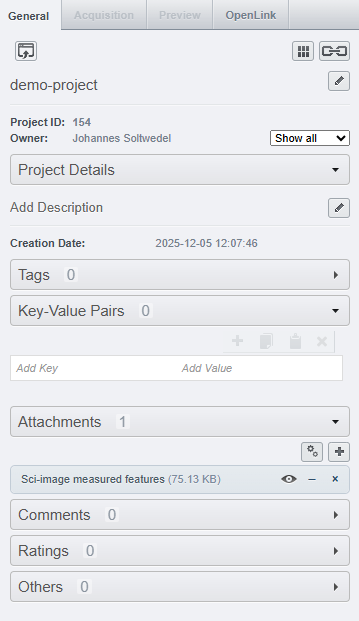

When we navigate to one of the images in either of the datasets, we can see that the table appears under the `Tables` tab. And not just that - OMERO automatically filters out the rows of the table that correspond to the specific image we are looking at:

 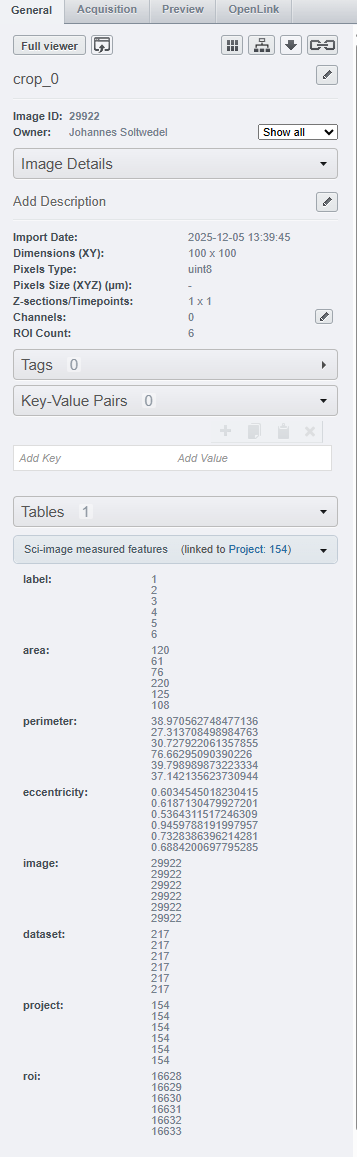

 ## Read from OMERO

Let's go the other way around and retrieve the tabular data from OMERO.tables.
The challenge here is, that OMERO tables (as weÄve learned above) are not necessarily directly associated with a specific image,
but can be linked to projects, datasets, images, or ROIs.

For any given image, tables can essentially be linked in three different ways:
1. Table linked directly to the image
2. Table linked to the dataset the image belongs to
3. Table linked to the project the image belongs to

That means, we need to check all three locations to be sure to retrieve all tables associated with a given image.
Let's pick a single image and try to find the related features!

In [8]:
image_id = 	29941
image_wrapper, _ = ezomero.get_image(conn, image_id=image_id, no_pixels=True, across_groups=False)

Links in OMERO are distinct objects that can be retrieved from the linked objects and have their own ids:

In [11]:
project_annotations = [ann.getId() for ann in image_wrapper.getProject().listAnnotations()]
dataset_annotations = [ann.getId() for ann in image_wrapper.getParent().listAnnotations()]
image_annotations = [ann.getId() for ann in image_wrapper.listAnnotations()]
print(f"Found {len(project_annotations)} project annotations, {len(dataset_annotations)} dataset annotations, and {len(image_annotations)} image annotations.")

annotation_ids = list(set(project_annotations + dataset_annotations + image_annotations))  # Remove duplicates
print(f"Remaining annotation_ids: {len(annotation_ids)} (IDs: {annotation_ids})")

Found 1 project annotations, 0 dataset annotations, and 0 image annotations.
Remaining annotation_ids: 1 (IDs: [511])


Before we load all the tables (which can be slow for large tables),
we read the column headers of the stored tables.
That way, we can directly check, whether the `image` and `roi` columns are present, which allow us to filter out the correct rows pertaining to our image of interest.

```{note}
It *can* happen that multiple tables are associated with the same objects (i.e., images or rois) - think about multiple measurements using different tools for the same segmentation results. TO make sure we can distinguish between these tables, we add a suffix to all columns (except the "magic" ones) based on the annotation ID of the table. This is just a safety precaution; If you are sure that there is only a single table per object, you can simplify the following step.
```

In [12]:
# Load only tables that have 'roi' column
tables = []

for i, annotation_id in enumerate(annotation_ids):
    columns = omero2pandas.get_table_columns(annotation_id=annotation_id, omero_connector=image_wrapper._conn)
    if "roi" not in columns:
        continue
        
    table = omero2pandas.read_table(annotation_id=annotation_id, omero_connector=image_wrapper._conn)
    print(annotation_id)
    
    # Add suffix to non-magic columns
    table.columns = [col if col in magic_properties else f"{col}_table{annotation_id}" for col in table.columns]
    tables.append(table)

511


We now merge the (possibly multiple) tables into a single dataframe for easier handling.
Luckily, the "magic" columns provid a good handle to merge on.

In [13]:
# Merge all tables
if len(tables) == 0:
    df = pd.DataFrame()
elif len(tables) == 1:
    df = tables[0]
else:
    df = tables[0]
    for table in tables[1:]:
        df = pd.merge(df, table, on=magic_properties)

df = df[df['image'] == image_id]
df

,label_table511,area_table511,perimeter_table511,eccentricity_table511,image,dataset,project,roi
0,1,77.0,29.899495,0.684930,29941,217,154,16808
1,2,87.0,33.556349,0.590655,29941,217,154,16809
2,3,81.0,31.313708,0.628315,29941,217,154,16810
3,4,111.0,36.384776,0.652672,29941,217,154,16811
4,5,80.0,30.727922,0.671234,29941,217,154,16812
5,6,107.0,36.970563,0.682472,29941,217,154,16813
6,7,111.0,37.213203,0.557650,29941,217,154,16814
7,8,189.0,59.455844,0.874892,29941,217,154,16815
8,9,139.0,42.041631,0.554284,29941,217,154,16816
9,10,132.0,39.798990,0.291678,29941,217,154,16817
